In [1]:
# Importing things I need
import scirpy as ir
import scanpy as sc
from glob import glob
import pandas as pd
import tarfile
import anndata
import warnings
import scanpy as sc
import anndata as an
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Importing and general exploration of Treg subclusters

In [4]:
# Read in filtered_all_tcr and merge accordingly with scRNAseq data
filtered_all_tcr = pd.read_csv("gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/meta_patient_TCRs/filtered_all_tcr_042025.csv", sep = ',')

treg_meta = pd.read_csv('gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/HC_Tclus/treg_meta_final.csv', sep=',')

#pull down from cluster column humap_fgraph_res.0.2 to get the subcluster dataframes
# act_treg = pd.read_csv('act_treg.csv', sep=',')
# foxp3_cd8 = pd.read_csv('foxp3_cd8.csv', sep=',')
# naive_treg = pd.read_csv('naive_treg.csv',sep = ',')

cd8_pre_label_transfer = pd.read_csv('gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/HC_Tclus/cd8t_quick_cluster2.csv', sep=',')
cd4_pre_label_transfer = pd.read_csv('gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/HC_Tclus/cd4_t_full.csv', sep=',')

# from foxp3_cd8, gate on CD8A and CD4 expression to make the below
# foxp3_cd8_0CD8_0CD4 = pd.read_csv('foxp3_cd8_0CD8_0CD4.csv')
# foxp3_cd8_0CD8_CD4 = pd.read_csv('foxp3_cd8_0CD8_CD4.csv')
# foxp3_cd8_CD8_0CD4 = pd.read_csv('foxp3_cd8_CD8_0CD4.csv')
# foxp3_cd8_CD8_CD4 = pd.read_csv('foxp3_cd8_CD8_CD4.csv')


filtered_all_tcr['barcode'] = filtered_all_tcr['barcode'].str.split('-').str[0]
# print(filtered_all_tcr)

def splice_id(df):
    df['cell_id'] = df['cell_id'].str.split('-').str[0]
    return df
# foxp3_cd8_meta = (splice_id(foxp3_cd8))
# act_treg_meta = (splice_id(act_treg))
# naive_treg_meta = (splice_id(naive_treg))

cd8_pre_lt_meta = (splice_id(cd8_pre_label_transfer))
cd4_pre_lt_meta = (splice_id(cd4_pre_label_transfer))
treg_meta = (splice_id(treg_meta))


# foxp3_cd8_0CD8_0CD4_meta = splice_id(foxp3_cd8_0CD8_0CD4)
# foxp3_cd8_0CD8_CD4_meta = splice_id(foxp3_cd8_0CD8_CD4)
# foxp3_cd8_CD8_0CD4_meta = splice_id(foxp3_cd8_CD8_0CD4)
# foxp3_cd8_CD8_CD4_meta = splice_id(foxp3_cd8_CD8_CD4)

# merge with TCRs
matching_treg_pre_lt = pd.merge(
    treg_meta,
    filtered_all_tcr,
    left_on=['cell_id', 'specimenID'],  # Columns from cd8_post_lt_meta
    right_on=['barcode', 'patient 10x channel'],  # Columns from filtered_all_tcr
    how='inner'
)
matching_cd8_cells_pre_lt = pd.merge(
    cd8_pre_lt_meta,
    filtered_all_tcr,
    left_on=['cell_id', 'specimenID'],  # Columns from cd8_post_lt_meta
    right_on=['barcode', 'patient 10x channel'],  # Columns from filtered_all_tcr
    how='inner'
)
matching_cd4_cells_pre_lt = pd.merge(
    cd4_pre_lt_meta,
    filtered_all_tcr,
    left_on=['cell_id', 'specimenID'],  # Columns from cd8_post_lt_meta
    right_on=['barcode', 'patient 10x channel'],  # Columns from filtered_all_tcr
    how='inner'
)

/tmp/ipykernel_276/611589162.py:2: DtypeWarning: Columns (23,24,25,26,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  filtered_all_tcr = pd.read_csv("gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/meta_patient_TCRs/filtered_all_tcr_042025.csv", sep = ',')


0.012279659338482869
0.0029708853238265003
0.003367003367003367
0.0017825311942959
0.0041592394533571005
0.0029708853238265003
0.003367003367003367
0.0023767082590612004
0.003763121410180234
0.0031689443454149336
0.0025747672806496337
0.0017825311942959
0.002772826302238067
0.004357298474945534
0.0007922360863537334
0.0019805902158843334
0.002772826302238067
0.003763121410180234
0.003961180431768667
0.0023767082590612004
0.003763121410180234
0.004555357496533967
0.0015844721727074668
0.0007922360863537334
0.002772826302238067
0.003367003367003367
0.0007922360863537334
0.003763121410180234
0.0015844721727074668
0.0019805902158843334
0.0035650623885918
0.0029708853238265003
0.0023767082590612004
0.002772826302238067
0.0031689443454149336
0.002178649237472767
0.0031689443454149336
0.0041592394533571005
0.003763121410180234
0.0017825311942959
0.004951475539710834
0.0031689443454149336
0.003961180431768667
0.0019805902158843334
0.002178649237472767
0.0015844721727074668
0.004159239453357100

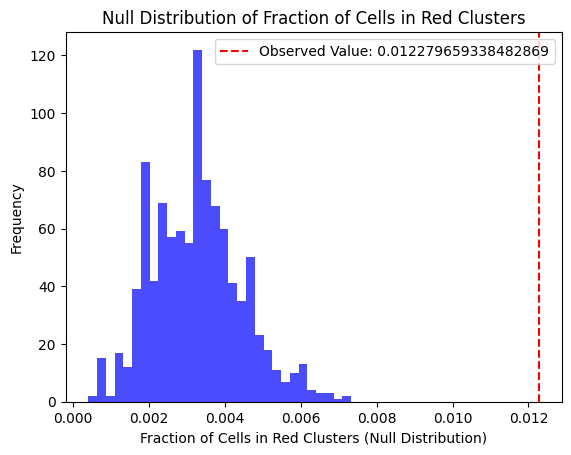

FDR for observed value 0.012279659338482869: 0.0
1.842112788966295e-57


In [5]:
# Do the TCR clones within the Tregs overlap between each cluster (i.e. activated Treg, resting Treg, FOXP3+ CD8)
def add_cdr3_combinations(df):
    df = df.copy()
    
    # Combine cdr3_alpha and cdr3_beta
    df['cdr3_alpha_beta'] = df['cdr3_alpha'].astype(str) + '_' + df['cdr3_beta'].astype(str)
    
    # Combine cdr3_alpha2 and cdr3_beta only if cdr3_alpha2 is not empty or NaN
    df['cdr3_alpha2_beta'] = df.apply(
        lambda row: f"{row['cdr3_alpha2']}_{row['cdr3_beta']}" 
        if pd.notna(row['cdr3_alpha2']) and row['cdr3_alpha2'] != '' else None,
        axis=1
    )
    
    return df
treg_w_tcr = add_cdr3_combinations(matching_treg_pre_lt)
# print(treg_w_tcr)


# Now assess clonal overlap
def count_cdr3_beta_fraction(df, cluster_col='humap_fgraph_res.0.2', clusters={1, 2}, specimen_col='specimenID', cdr3_col='cdr3_alpha_beta'):
    """    
    Parameters:
    df (pd.DataFrame): Input dataframe.
    cluster_col (str): Column name containing cluster numbers.
    clusters (set): Clusters to consider for presence in cdr3_alpha_beta sequence.
    specimen_col (str): Column name for specimen ID.
    cdr3_col (str): Column containing cdr3_alpha_beta sequence.
    
    Returns:
    float: Fraction of cells meeting the criteria over the total number of cells in the dataframe.
    """
    total_cells = len(df)
    if total_cells == 0:
        return 0.0
    
    count = 0
    
    for specimen_id, group in df.groupby(specimen_col):
        cdr3_cluster_map = group.groupby(cdr3_col)[cluster_col].apply(set)
        valid_cdr3 = cdr3_cluster_map[cdr3_cluster_map.apply(lambda x: clusters.issubset(x))].index
        count += group[group[cdr3_col].isin(valid_cdr3)].shape[0]
#     print(count)
#     print(total_cells)
    return count / total_cells

observed_fraction_in_red_overlap = (count_cdr3_beta_fraction(treg_w_tcr))
print(observed_fraction_in_red_overlap)

# Looking at clonal overlap, null_distribution_calculating fdr, can change cluster numbers to compare
def generate_null_distribution_overlap(data, cluster_col='humap_fgraph_res.0.2', clusters={1, 2}, specimen_col='specimenID', cdr3_col='cdr3_alpha_beta', num_iterations=1000):
    null_distribution = []
    scrambled_data = data.copy()

    for i in range(num_iterations):
        scrambled_data['cdr3_alpha_beta'] = np.random.permutation(scrambled_data['cdr3_alpha_beta'])
        fraction_in_red = count_cdr3_beta_fraction(scrambled_data, cluster_col='humap_fgraph_res.0.2', clusters={1, 2}, specimen_col='specimenID', cdr3_col='cdr3_alpha_beta')
        print(fraction_in_red)
        null_distribution.append(fraction_in_red)

    return null_distribution

null_distribution_in_red_overlap = generate_null_distribution_overlap(treg_w_tcr)

# Print all the results (null distribution) (optional)
# print(null_distribution_in_red)

# Plot the null distribution
plt.hist(null_distribution_in_red_overlap, bins=30, alpha=0.7, color='blue')
plt.axvline(x=observed_fraction_in_red_overlap, color='red', linestyle='--', label=f'Observed Value: {observed_fraction_in_red_overlap}')
plt.xlabel('Fraction of Cells in Red Clusters (Null Distribution)')
plt.ylabel('Frequency')
plt.title('Null Distribution of Fraction of Cells in Red Clusters')
plt.legend()
plt.show()


def calculate_fdr(observed_value, null_distribution):
    count_greater_equal = np.sum(np.array(null_distribution) >= observed_value)
    fdr = count_greater_equal / len(null_distribution)
    return fdr


fdr_value = calculate_fdr(observed_fraction_in_red_overlap, null_distribution_in_red_overlap)

print(f"FDR for observed value {observed_fraction_in_red_overlap}: {fdr_value}")

from scipy.stats import norm
p_value = 2 * norm.sf(abs(15.97720894))  # Two-tailed test
print(p_value)


In [19]:
# adata object importing
adata = an.read('adata_18_144')
import pandas as pd
anno = pd.read_csv('gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/data_minGenes_noDnsmpl/metadata_minGenes_noDnsmpl.txt.gz', sep='\t')
adata.obs = anno
sc.pp.filter_genes(adata, min_cells=10)
anno
print(len(adata))

/home/jupyter/.local/lib/python3.10/site-packages/anndata/__init__.py:42: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(
/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


327418


In [20]:
# merging functions and code
adata_T = adata[adata.obs['category'] == 'T']
adata_T = adata_T[adata_T.obs['pct_counts_mt'] <= 15]
sc.pp.filter_cells(adata_T, min_genes=200)
sc.pp.filter_genes(adata_T, min_cells=3)

treg_meta = pd.read_csv('gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/HC_Tclus/treg_meta_final.csv', sep=',')


#processing
def clean_and_merge_data(adata, t_meta_coords):
    adata_cleaned = adata.copy()

    if 'Unnamed: 0' in adata_cleaned.obs.columns:
        adata_cleaned.obs.rename(columns={'Unnamed: 0': 'cell_id'}, inplace=True)

    adata_cleaned.obs['cell_id'] = adata_cleaned.obs['cell_id'].astype(str)
    adata_cleaned.obs['specimenID'] = adata_cleaned.obs['specimenID'].astype(str)
    t_meta_coords['cell_id'] = t_meta_coords['cell_id'].astype(str)
    t_meta_coords['specimenID'] = t_meta_coords['specimenID'].astype(str)

    # Perform the merge
    adata_cleaned.obs = pd.merge(adata_cleaned.obs, t_meta_coords, how='left', on=['cell_id', 'specimenID'])
    adata_cleaned.obs = adata_cleaned.obs.loc[:, ~adata_cleaned.obs.columns.duplicated()]

    # Drop '_x' and '_y' suffixes if present
    suffixes_to_drop = ['_x', '_y']
    for suffix in suffixes_to_drop:
        columns_to_drop = [col for col in adata_cleaned.obs.columns if col.endswith(suffix) and col.rstrip(suffix) in adata_cleaned.obs.columns]
        adata_cleaned.obs.drop(columns=columns_to_drop, inplace=True)

    return adata_cleaned

data_treg_subset = clean_and_merge_data(adata_T, treg_meta)

def filter_adata_by_nan_v1(adata):
    if 'humap_fgraph_res.0.2' not in adata.obs.columns:
        print("Error: 'humap_fgraph_res.0.2' column not found!")
        return None
    return adata[~adata.obs['humap_fgraph_res.0.2'].isna()]

data_treg_subset = filter_adata_by_nan_v1(data_treg_subset)

# more processing
data_treg_subset.var_names = data_treg_subset.var_names.astype(str)

def convert_columns_to_str(adata, columns):
    for col in columns:
        if col in adata.obs.columns:
            adata.obs[col] = adata.obs[col].astype(str)

lst_str_cols = ['orig.ident', 'sampleID', ' specimenID', ' patientID', ' treatment', ' tissueSite', ' response', 
                'MMRstatus',  'pctChangeNoPre', 'category','midcategory','RECIST','sex','resp_tx','phase',
                'resolutionL1', 'cell_type_L1', 'resolution_L2','cell_type_L2','cell_type_L2_long','jon_cell_type']

convert_columns_to_str(data_treg_subset, lst_str_cols)


/home/jupyter/.local/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_genes"] = number
/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


# Fig 4G

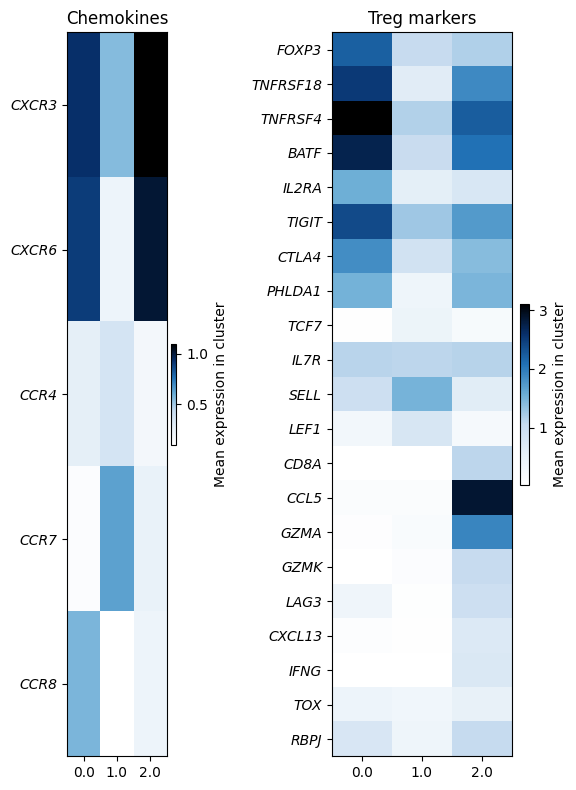

In [36]:
# Feature plot code for Treg subclusters
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from matplotlib.colors import LinearSegmentedColormap

adata = data_treg_subset
cluster_col = "humap_fgraph_res.0.2"

chemokine_genes = ["CXCR3", "CXCR6", "CCR4", "CCR7", "CCR8"]

marker_genes = [
    "FOXP3", "TNFRSF18", "TNFRSF4", "BATF", "IL2RA", "TIGIT", "CTLA4",
    "PHLDA1", "TCF7", "IL7R", "SELL", "LEF1", "CD8A", "CCL5", "GZMA",
    "GZMK", "LAG3", "CXCL13", "IFNG", "TOX", "RBPJ"
]

# white -> light blue -> dark blue
cmap = LinearSegmentedColormap.from_list(
    "blue_to_black",
    [
        "#ffffff",   # white
        "#e6f0f8",   # very light blue
        "#c6dbef",   # light blue
        "#6baed6",   # medium blue
        "#2171b5",   # strong blue
        "#08306b",   # dark blue
        "#000000"    # near black
    ]
)
def mean_expression_by_cluster(adata, genes, cluster_col):
    genes_present = [g for g in genes if g in adata.var_names]
    if len(genes_present) == 0:
        raise ValueError("None of the requested genes were found in adata.var_names")

    obs = adata.obs[[cluster_col]].copy()
    obs = obs[obs[cluster_col].notna()].copy()

    ad = adata[obs.index, genes_present].copy()
    X = ad.X
    if sparse.issparse(X):
        X = X.toarray()

    expr = pd.DataFrame(X, index=ad.obs_names, columns=genes_present)
    expr[cluster_col] = obs.loc[expr.index, cluster_col].astype(str).values

    mean_expr = expr.groupby(cluster_col).mean().T

    # sort cluster columns numerically when possible
    try:
        sorted_cols = sorted(mean_expr.columns, key=lambda x: float(x))
        mean_expr = mean_expr[sorted_cols]
    except:
        pass

    return mean_expr

chemokine_mat = mean_expression_by_cluster(adata, chemokine_genes, cluster_col)
marker_mat = mean_expression_by_cluster(adata, marker_genes, cluster_col)

fig, axes = plt.subplots(
    1, 2, figsize=(6, 8),
    gridspec_kw={"width_ratios": [1, 1.8]}
)

# left heatmap
im1 = axes[0].imshow(
    chemokine_mat.values,
    aspect="auto",
    cmap=cmap
)
axes[0].set_yticks(np.arange(len(chemokine_mat.index)))
axes[0].set_yticklabels(chemokine_mat.index, fontstyle="italic")
axes[0].set_xticks(np.arange(len(chemokine_mat.columns)))
axes[0].set_xticklabels(chemokine_mat.columns)
axes[0].set_title("Chemokines")

# right heatmap
im2 = axes[1].imshow(
    marker_mat.values,
    aspect="auto",
    cmap=cmap
)
axes[1].set_yticks(np.arange(len(marker_mat.index)))
axes[1].set_yticklabels(marker_mat.index, fontstyle="italic")
axes[1].set_xticks(np.arange(len(marker_mat.columns)))
axes[1].set_xticklabels(marker_mat.columns)
axes[1].set_title("Treg markers")

# colorbars
cbar1 = plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
cbar1.set_label("Mean expression in cluster")

cbar2 = plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
cbar2.set_label("Mean expression in cluster")

plt.tight_layout()
plt.savefig("chemokine_treg_cluster_heatmap.pdf", dpi=300, bbox_inches="tight")
plt.show()


# Fig 4H, Fig S5C

In [39]:
# adata object importing and making anndata objects for Treg subclusters
adata = an.read('adata_18_144')
import pandas as pd
anno = pd.read_csv('gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/data_minGenes_noDnsmpl/metadata_minGenes_noDnsmpl.txt.gz', sep='\t')
adata.obs = anno
sc.pp.filter_genes(adata, min_cells=10)
anno
print(len(adata))

adata_T = adata[adata.obs["category"] == "T"].copy()
adata_T = adata_T[adata_T.obs["pct_counts_mt"] <= 15].copy()

sc.pp.filter_cells(adata_T, min_genes=200)
sc.pp.filter_genes(adata_T, min_cells=3)
treg_meta = pd.read_csv("gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/HC_Tclus/treg_meta_final.csv")
cluster_col = "humap_fgraph_res.0.2"

def clean_and_merge_data_fast(adata, meta, cluster_col):
    ad = adata.copy()
    meta = meta.copy()

    # standardize key columns
    if "Unnamed: 0" in ad.obs.columns and "cell_id" not in ad.obs.columns:
        ad.obs = ad.obs.rename(columns={"Unnamed: 0": "cell_id"})

    ad.obs["cell_id"] = ad.obs["cell_id"].astype(str)
    ad.obs["specimenID"] = ad.obs["specimenID"].astype(str)
    meta["cell_id"] = meta["cell_id"].astype(str)
    meta["specimenID"] = meta["specimenID"].astype(str)

    # only bring in columns not already present + merge keys
    keep_cols = ["cell_id", "specimenID"]
    if cluster_col in meta.columns:
        keep_cols.append(cluster_col)

    extra_cols = [c for c in meta.columns if c not in ad.obs.columns and c not in keep_cols]
    meta_sub = meta[keep_cols + extra_cols].copy()

    # merge
    obs_merged = ad.obs.merge(
        meta_sub,
        how="left",
        on=["cell_id", "specimenID"],
        suffixes=("", "_meta")
    )

    # remove accidental duplicate suffix cols
    dup_meta_cols = [c for c in obs_merged.columns if c.endswith("_meta")]
    if dup_meta_cols:
        obs_merged = obs_merged.drop(columns=dup_meta_cols)

    ad.obs = obs_merged
    return ad

data_treg_subset = clean_and_merge_data_fast(adata_T, treg_meta, cluster_col=cluster_col)

if cluster_col not in data_treg_subset.obs.columns:
    raise ValueError(f"{cluster_col} not found in merged adata.obs")

data_treg_subset = data_treg_subset[~data_treg_subset.obs[cluster_col].isna()].copy()
data_treg_subset.obs[cluster_col] = data_treg_subset.obs[cluster_col].astype(str)

data_treg_subset.var_names = data_treg_subset.var_names.astype(str)

lst_str_cols = [
    "orig.ident", "sampleID", " specimenID", " patientID", " treatment", " tissueSite", " response",
    "MMRstatus", "pctChangeNoPre", "category", "midcategory", "RECIST", "sex", "resp_tx", "phase",
    "resolutionL1", "cell_type_L1", "resolution_L2", "cell_type_L2", "cell_type_L2_long", "jon_cell_type"
]

lst_str_cols = [c.strip() for c in lst_str_cols]

for col in lst_str_cols:
    if col in data_treg_subset.obs.columns:
        data_treg_subset.obs[col] = data_treg_subset.obs[col].astype(str)

# Split into 3 cluster-specific AnnData objects
present_clusters = sorted(data_treg_subset.obs[cluster_col].unique(), key=lambda x: float(x))
print("Clusters present:", present_clusters)

data_act_treg_subset = data_treg_subset[data_treg_subset.obs[cluster_col] == "0.0"].copy()
data_naive_treg_subset = data_treg_subset[data_treg_subset.obs[cluster_col] == "1.0"].copy()
data_foxp3_cd8_subset = data_treg_subset[data_treg_subset.obs[cluster_col] == "2.0"].copy()

print("cluster 0:", data_act_treg_subset.shape)
print("cluster 1:", data_naive_treg_subset.shape)
print("cluster 2:", data_foxp3_cd8_subset.shape)

/home/jupyter/.local/lib/python3.10/site-packages/anndata/__init__.py:42: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(
/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


327418


/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Clusters present: ['0.0', '1.0', '2.0']
cluster 0: (3699, 26356)
cluster 1: (3040, 26356)
cluster 2: (783, 26356)


/tmp/ipykernel_276/3991585713.py:4: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  merged_data = sc.AnnData.concatenate(data_foxp3_cd8_subset, data_act_treg_subset, join='outer')


foxp3_pos
no     3699
yes     783
Name: count, dtype: int64


/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/jupyter/.local

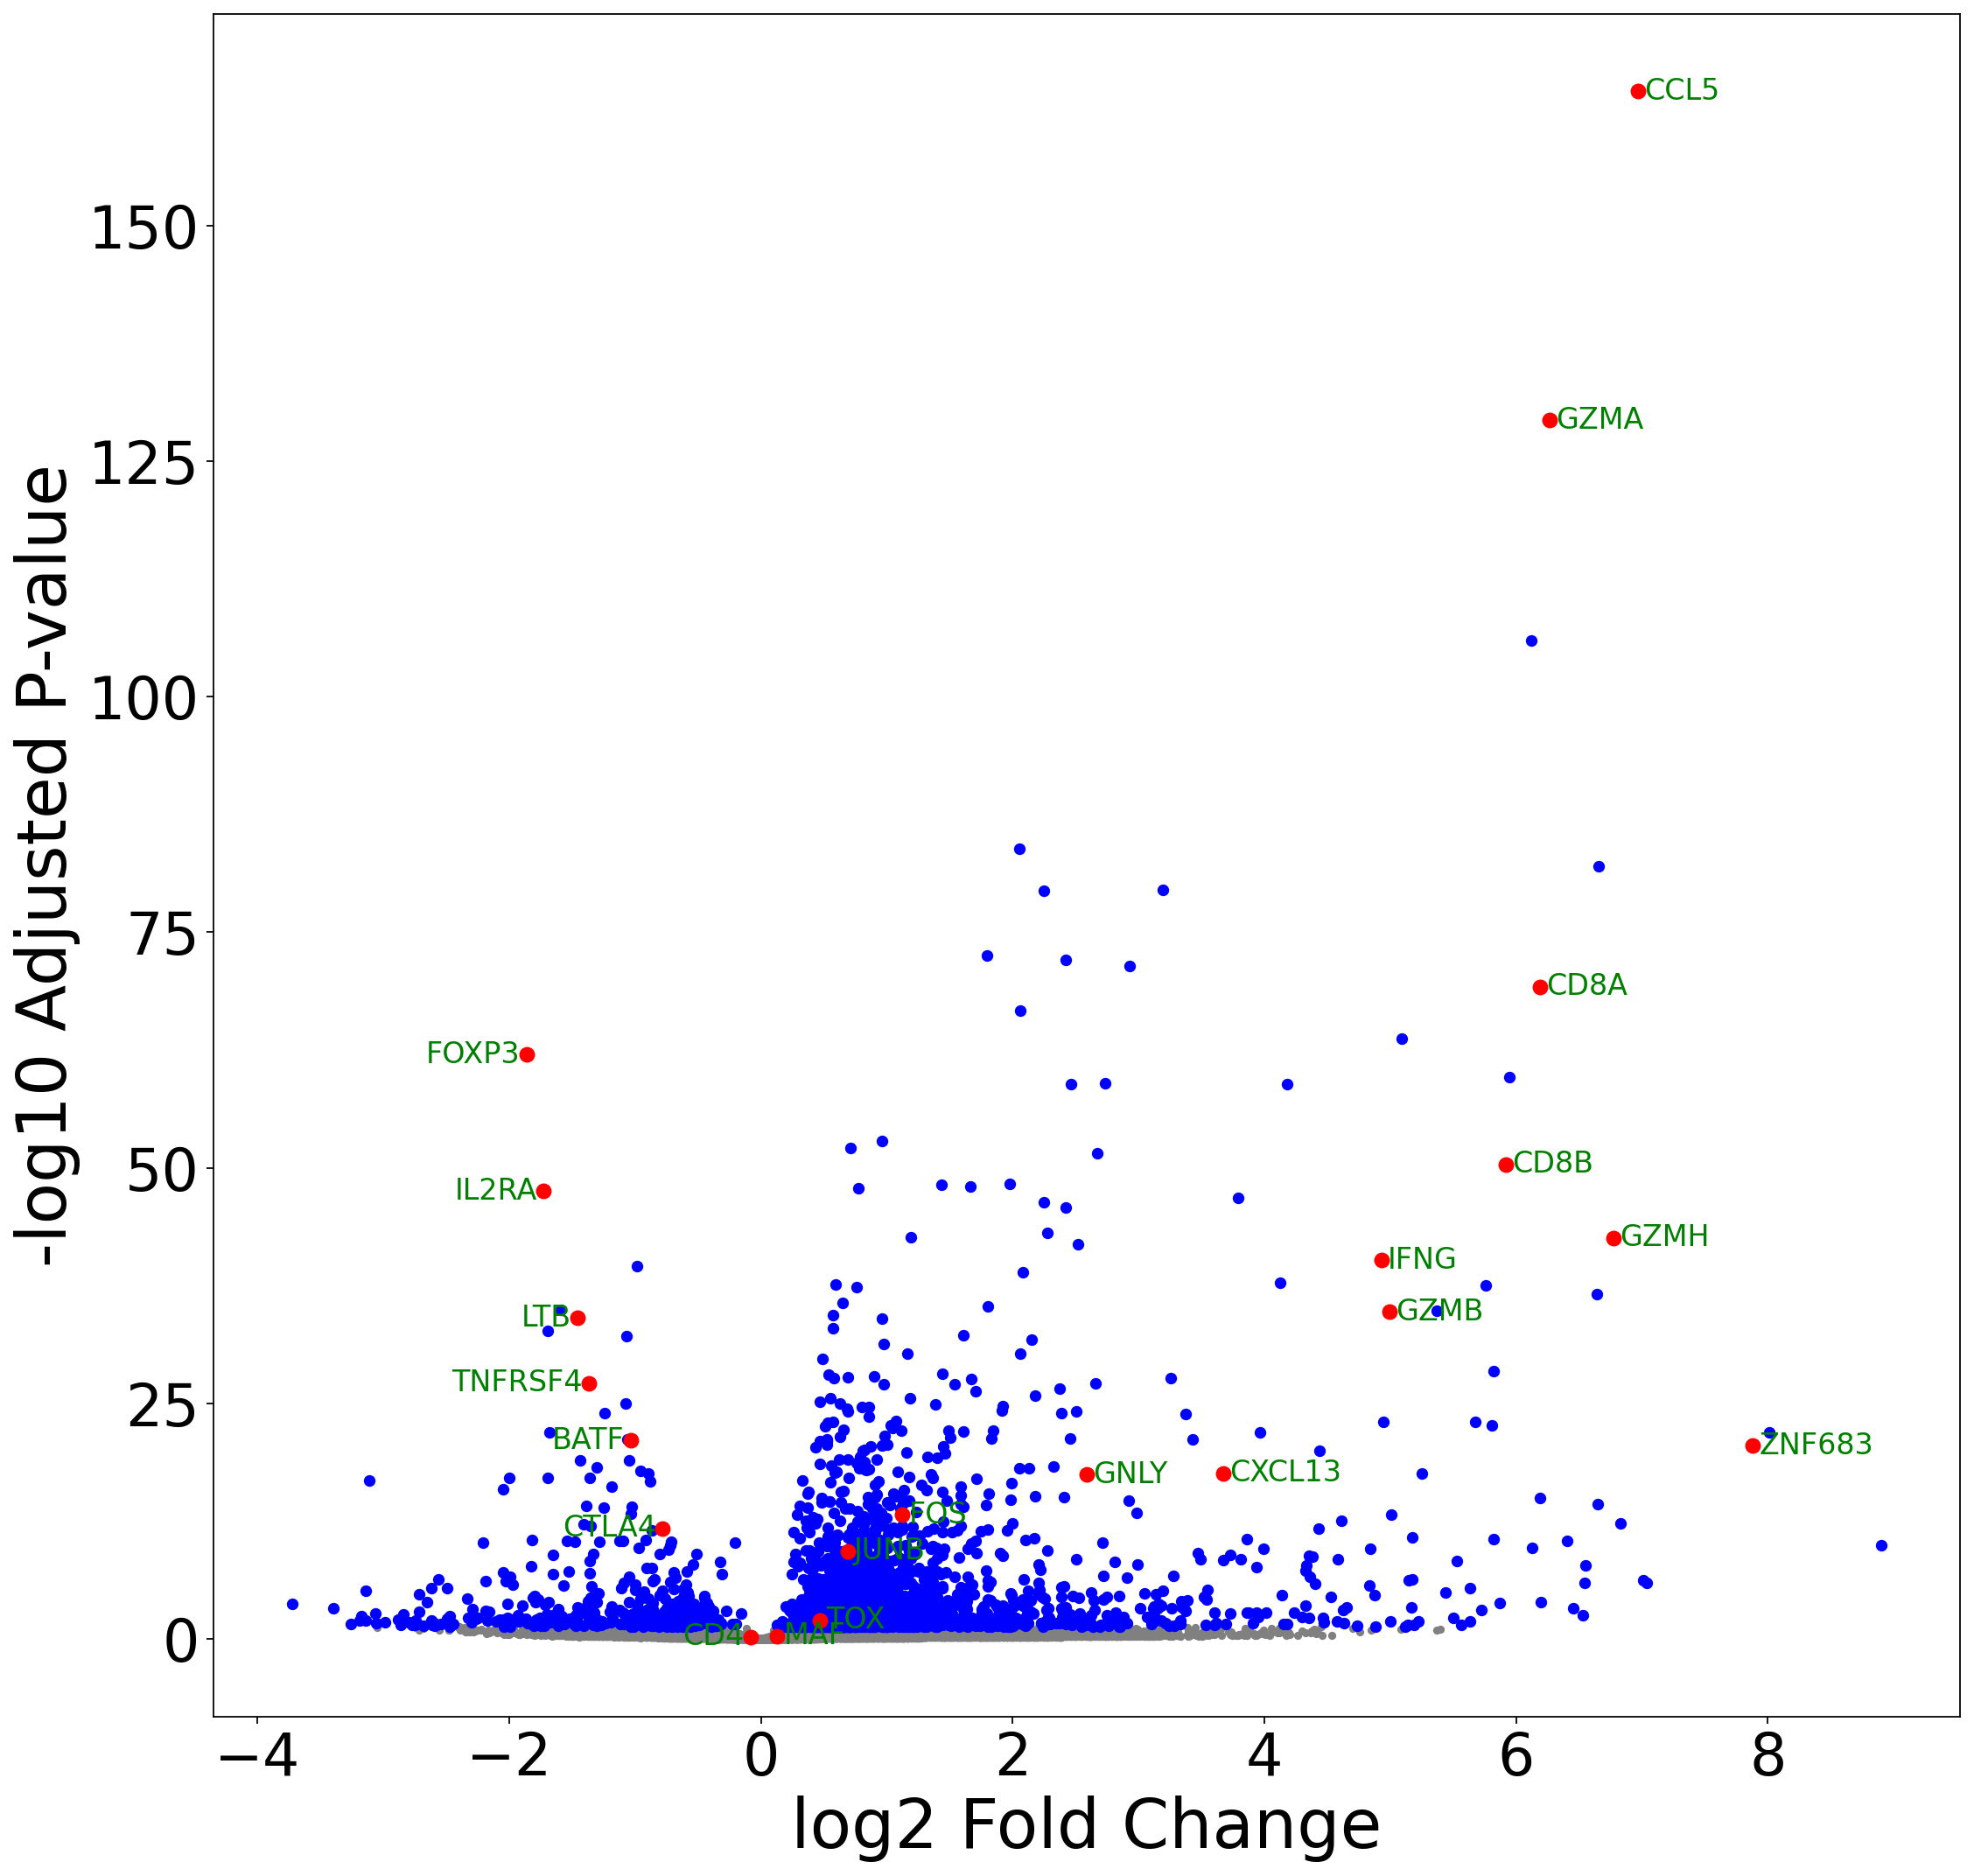

        names     scores  logfoldchanges          pvals      pvals_adj  \
0        CCL5  35.888569        6.968317  2.886944e-169  5.990120e-165   
1        GZMA  30.119587        6.268650  4.647326e-134  4.821368e-130   
2        NKG7  26.323797        6.120124  1.693377e-110  1.171196e-106   
3        CCL4  22.359179        6.657704   2.190315e-86   9.089368e-83   
4      GIMAP7  21.621946        3.192411   9.944536e-84   3.438986e-80   
...       ...        ...             ...            ...            ...   
20744   RTKN2 -13.246067       -1.591064   2.616735e-38   1.206547e-35   
20745     LTB -13.267096       -1.458742   1.919154e-37   8.126637e-35   
20746    IL32 -14.349360       -0.982999   4.851716e-43   2.796340e-40   
20747   IL2RA -15.614681       -1.727981   4.007403e-51   3.079615e-48   
20748   FOXP3 -18.146894       -1.861778   6.302315e-66   9.340481e-63   

         log_pval  
0      164.222565  
1      129.316830  
2      105.931370  
3       82.041466  
4       79.

In [41]:
# Can merge different anndata objects to make volcano plot
data_foxp3_cd8_subset.obs['foxp3_pos'] = 'yes'
data_act_treg_subset.obs['foxp3_pos'] = 'no'
merged_data = sc.AnnData.concatenate(data_foxp3_cd8_subset, data_act_treg_subset, join='outer')
print(merged_data.obs['foxp3_pos'].value_counts())

def deg_res(adata):
    adata.var['nonz_variance'] = (adata.X > 0).sum(axis=0).A.squeeze()
    
    adata = adata[:, adata.var['nonz_variance'] > 0]
    sc.tl.rank_genes_groups(adata, 'foxp3_pos', method='t-test')

    return sc.get.rank_genes_groups_df(adata, group='yes')

mydf_res = deg_res(merged_data)

# Volcano plot function

def vol_plot(df_something, labeled_genes, p_value_cutoff=0.05, fold_change_cutoff=0, log_pval_cutoff=0, save_path=None):
    # Define significant genes
    significant_genes = (
        (df_something['pvals_adj'] < p_value_cutoff) &
        (np.abs(df_something['logfoldchanges']) > np.log2(fold_change_cutoff))
    )
    
    # Create a mask for labeled genes
    labeled_genes_mask = df_something['names'].isin(labeled_genes)
    
    # Cap -log10(pvals_adj) at 250
    df_something['log_pval'] = df_something['pvals_adj'].apply(lambda x: min(-np.log10(x), 250))

    # Plotting
    plt.figure(figsize=(16, 16))

    # Plot non-significant genes
    plt.scatter(
        x=df_something[~significant_genes]['logfoldchanges'], 
        y=df_something[~significant_genes]['log_pval'], 
        s=10, label="Not significant", c='gray'
    )

    # Plot significant genes
    plt.scatter(
        x=df_something[significant_genes]['logfoldchanges'], 
        y=df_something[significant_genes]['log_pval'], 
        s=25, label="Significant", c='blue'
    )

    # Plot and annotate labeled genes
    labeled = df_something[labeled_genes_mask]
    plt.scatter(
        x=labeled['logfoldchanges'], 
        y=labeled['log_pval'], 
        s=50, label="Labeled genes", c='red'
    )

    for gene, x, y in zip(labeled['names'], labeled['logfoldchanges'], labeled['log_pval']):
        ha = 'left' if x > 0 else 'right'
        plt.annotate(gene, (x + (0.05 if x > 0 else -0.05), y), fontsize=15, ha=ha, va='center', color='green')

    # Formatting
    plt.xticks(fontsize=30)
    plt.yticks(fontsize=30)
    plt.xlabel("log2 Fold Change", fontsize=35)
    plt.ylabel("-log10 Adjusted P-value", fontsize=35)
#     plt.legend(fontsize=20)
    plt.grid(False)

    # Save if path is provided
    if save_path:
        plt.savefig(save_path, format='pdf', dpi=300, bbox_inches='tight')
        plt.show()

    plt.close()

    
# Volcano plot output
df_res_sub_10 = mydf_res[abs(mydf_res['logfoldchanges']) < 10]
df_res_gte_10 = mydf_res[abs(mydf_res['logfoldchanges']) >= 10]

sc.set_figure_params(facecolor="white", figsize=(16, 16))


labeled = ['CD8A','GZMB','CCL5','CD8B','GZMH','GZMA','CXCL13','GNLY','IFNG','ZNF683',
           'BATF','MAF','CTLA4','IL2RA','FOS','JUNB','CD4','IL2RA','TNFRSF4','LTB','FOXP3','TOX']
vol_plot(df_res_sub_10, labeled)
vol_plot(df_res_sub_10, labeled, save_path='foxp3_cd8_vs_cxcl13_cd8.pdf')

print(df_res_sub_10)
print(df_res_sub_10.head(50))
print(df_res_sub_10.tail(50))

# Investigating FOXP3 CD8 cluster TCR overlap in CD4 and CD8 T cell compartments

In [51]:
# Assessing clonal overlap between FOXP3 CD8 cluster and other CD4 and all CD8 T cell populations
def add_cdr3_combinations(df):
    df = df.copy()
    
    # Combine cdr3_alpha and cdr3_beta
    df['cdr3_alpha_beta'] = df['cdr3_alpha'].astype(str) + '_' + df['cdr3_beta'].astype(str)
    
    # Combine cdr3_alpha2 and cdr3_beta only if cdr3_alpha2 is not empty or NaN
    df['cdr3_alpha2_beta'] = df.apply(
        lambda row: f"{row['cdr3_alpha2']}_{row['cdr3_beta']}" 
        if pd.notna(row['cdr3_alpha2']) and row['cdr3_alpha2'] != '' else None,
        axis=1
    )
    
    return df
foxp3_cd8_w_tcr = add_cdr3_combinations(treg_w_tcr[treg_w_tcr['humap_fgraph_res.0.2'] == 2])
cd8_w_tcr = add_cdr3_combinations(matching_cd8_cells_pre_lt)
cd4_w_tcr  = add_cdr3_combinations(matching_cd4_cells_pre_lt)
# matching_foxp3_cd8_0CD8_0CD4_w_tcr = add_cdr3_combinations(matching_foxp3_cd8_0CD8_0CD4)
# matching_foxp3_cd8_0CD8_CD4_w_tcr = add_cdr3_combinations(matching_foxp3_cd8_0CD8_CD4)
# matching_foxp3_cd8_CD8_0CD4_w_tcr = add_cdr3_combinations(matching_foxp3_cd8_CD8_0CD4)
# matching_foxp3_cd8_CD8_CD4_w_tcr = add_cdr3_combinations(matching_foxp3_cd8_CD8_CD4)

subset_matching_TCR_pre_lt = cd8_w_tcr[
    cd8_w_tcr.set_index(['specimenID', 'cdr3_alpha_beta']).index.isin(
        foxp3_cd8_w_tcr.set_index(['specimenID', 'cdr3_alpha_beta']).index
    )
]
# print(subset_matching_TCR_pre_lt)

# Fig S5E

In [53]:
# UMAP for CD8s and CD4s that overlap 
# plt.figure(figsize=(176, 128))

# cluster_labels = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2', 3: 'Cluster 3', 4: 'MHCII/PFN1',
#                   5: 'Cluster 5', 6: 'Cluster 6', 7: 'CXCL13', 8: 'HOBIT_0', 9: 'MHCII/KLRG1',
#                   10: 'Cluster 10', 11: 'Cluster 11', 12: 'Cluster 12', 13: 'HOBIT_1'}


# cd8_pre_lt_clus = [cd8_w_tcr[cd8_w_tcr['sub_humap_fgraph_res.1'] == i] for i in range(14)]

# cluster_colors = {i: '#D3D3D3' for i in range(14)}  # Default to light grey
# cluster_colors[7] = '#FFA07A'  # Light red for Cluster 7

# for i, clusters in enumerate(cd8_pre_lt_clus):
#     plt.scatter(clusters.iloc[:, 111], clusters.iloc[:, 112], 
#                 label=cluster_labels.get(i, f'Treg subcluster {i}'), 
#                 s=3000, edgecolors='none', color=cluster_colors[i])

# plt.scatter(subset_matching_TCR_pre_lt.iloc[:, 111], subset_matching_TCR_pre_lt.iloc[:, 112], 
#             label='Treg Clones Pre LT', s=4000, c='black', marker='^')

# plt.savefig("cd8_umap_with_foxp3_cd8_TCR.pdf", format="pdf", bbox_inches="tight")

# # UMAP for CD4
# plt.figure(figsize=(176, 128))

# subset_matching_TCR_pre_lt_2 = cd4_w_tcr[
#     cd4_w_tcr.set_index(['specimenID', 'cdr3_alpha_beta']).index.isin(
#         foxp3_cd8_w_tcr.set_index(['specimenID', 'cdr3_alpha_beta']).index
#     )
# ]

# subset_matching_TCR_pre_lt_2 = subset_matching_TCR_pre_lt_2[subset_matching_TCR_pre_lt_2['humap_fgraph_res.0.9'] != 2]


# cluster_labels = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Treg', 3: 'Cluster 3', 4: 'Cluster 4',
#                  5: 'Cluster 5', 6: 'Cluster 6', 7: 'Cluster 7', 8: 'Cluster 8', 9: 'CXCL13',
#                  10: 'Cluster 10', 11: 'Cluster 11'}

# cd4_pre_lt_clus = [cd4_w_tcr[cd4_w_tcr['humap_fgraph_res.0.9'] == i] for i in range(12)]

# cluster_colors = {i: '#D3D3D3' for i in range(12)}  # Default to light grey
# cluster_colors[9] = '#FFA07A'  # Light red for Cluster 9


# for i, clusters in enumerate(cd4_pre_lt_clus):
#     plt.scatter(clusters.iloc[:, 79], clusters.iloc[:, 80], 
#                 label=cluster_labels.get(i, f'CD4 T subcluster {i}'), 
#                 s=3000, edgecolors='none', color=cluster_colors[i])

# plt.scatter(subset_matching_TCR_pre_lt_2.iloc[:, 79], subset_matching_TCR_pre_lt_2.iloc[:, 80], 
#             label='Treg Clones in CD4', s=4000, c='black', marker='^')

# plt.savefig("cd4_umap_with_foxp3_cd8_TCR.pdf", format="pdf", bbox_inches="tight")


# Fig S5G, I, J, K

In [55]:
# Fisher's Exact
def analyze_clonotype_overlap(matching_foxp3_cd8_cells_pre_lt, matching_cd8_cells_pre_lt):
    # Get unique clonotypes from both dataframes
    foxp3_clonotypes = set(matching_foxp3_cd8_cells_pre_lt["cdr3_alpha_beta"].dropna().unique())
    cd8_clonotypes = set(matching_cd8_cells_pre_lt["cdr3_alpha_beta"].dropna().unique())

    # Find overlapping clonotypes
    shared_clonotypes = foxp3_clonotypes & cd8_clonotypes

    print(f"Number of overlapping clonotypes: {len(shared_clonotypes)}")

    # Subset cd8 df to shared clonotypes only
    shared_cd8_df = matching_cd8_cells_pre_lt[
        matching_cd8_cells_pre_lt["cdr3_alpha_beta"].isin(shared_clonotypes)
    ]

    # Shared clonotypes with sub_humap_fgraph_res.1 == 7
    shared_in_7 = set(
        shared_cd8_df[
            shared_cd8_df["sub_humap_fgraph_res.1"] == 7
        ]["cdr3_alpha_beta"].dropna().unique()
    )

    # Shared clonotypes with sub_humap_fgraph_res.1 != 7
    shared_not_7 = shared_clonotypes - shared_in_7

    print(f"Number of shared clonotypes with sub_humap_fgraph_res.1 == 7: {len(shared_in_7)}")
    print(f"Number of shared clonotypes with sub_humap_fgraph_res.1 != 7: {len(shared_not_7)}")

    # Clonotypes unique to foxp3
    foxp3_only = foxp3_clonotypes - cd8_clonotypes
    print(f"Number of unique clonotypes in matching_foxp3_cd8_cells_pre_lt not in matching_cd8_cells_pre_lt: {len(foxp3_only)}")

    # Clonotypes unique to cd8
    cd8_only = cd8_clonotypes - foxp3_clonotypes
    print(f"Number of unique clonotypes in matching_cd8_cells_pre_lt not in matching_foxp3_cd8_cells_pre_lt: {len(cd8_only)}")

    # Get all unique cd8 clonotypes with sub_humap_fgraph_res.1 == 7
    cd8_res7_clonotypes = set(
        matching_cd8_cells_pre_lt[
            matching_cd8_cells_pre_lt["sub_humap_fgraph_res.1"] == 7
        ]["cdr3_alpha_beta"].dropna().unique()
    )

    # Of those, how many do not overlap with foxp3
    res7_not_shared = cd8_res7_clonotypes - foxp3_clonotypes
    print(f"Number of unique clonotypes with sub_humap_fgraph_res.1 == 7 not in matching_foxp3_cd8_cells_pre_lt: {len(res7_not_shared)}")

    # Clonotypes not in res.1 == 7
    cd8_not_res7_clonotypes = set(
        matching_cd8_cells_pre_lt[
            matching_cd8_cells_pre_lt["sub_humap_fgraph_res.1"] != 7
        ]["cdr3_alpha_beta"].dropna().unique()
    )

    # Of those, how many do not overlap with foxp3
    not_res7_not_shared = cd8_not_res7_clonotypes - foxp3_clonotypes
    print(f"Number of unique clonotypes with sub_humap_fgraph_res.1 != 7 not in matching_foxp3_cd8_cells_pre_lt: {len(not_res7_not_shared)}")

analyze_clonotype_overlap(foxp3_cd8_w_tcr, cd8_w_tcr)

Number of overlapping clonotypes: 50
Number of shared clonotypes with sub_humap_fgraph_res.1 == 7: 24
Number of shared clonotypes with sub_humap_fgraph_res.1 != 7: 26
Number of unique clonotypes in matching_foxp3_cd8_cells_pre_lt not in matching_cd8_cells_pre_lt: 441
Number of unique clonotypes in matching_cd8_cells_pre_lt not in matching_foxp3_cd8_cells_pre_lt: 8441
Number of unique clonotypes with sub_humap_fgraph_res.1 == 7 not in matching_foxp3_cd8_cells_pre_lt: 634
Number of unique clonotypes with sub_humap_fgraph_res.1 != 7 not in matching_foxp3_cd8_cells_pre_lt: 8097


In [56]:
# Calculating Z-scores for TCR overlap, can switch out cluster numbers for CD8 T cells
def calculate_cluster_proportion(matching_cells, matching_foxp3_cells, cluster_column='sub_humap_fgraph_res.1', target_cluster=7):
    subset_matching_TCR = matching_cells[
        matching_cells.set_index(['specimenID', 'cdr3_alpha_beta']).index.isin(
            matching_foxp3_cells.set_index(['specimenID', 'cdr3_alpha_beta']).index
        )
    ]
    
    total_matching_cells = len(subset_matching_TCR)
    cluster_counts = subset_matching_TCR[cluster_column].value_counts()
    count_in_target_cluster = cluster_counts.get(target_cluster, 0)
    
    proportion_in_target_cluster = count_in_target_cluster / total_matching_cells if total_matching_cells > 0 else 0
    
    return proportion_in_target_cluster
def generate_null_distribution_overlap(matching_cells, matching_foxp3_cells, cluster_column='sub_humap_fgraph_res.1', target_cluster=7, num_iterations=1000):
    null_distribution = []
    scrambled_data = matching_cells.copy()

    for i in range(num_iterations):
        scrambled_data['cdr3_alpha_beta'] = np.random.permutation(scrambled_data['cdr3_alpha_beta'])
        proportion_in_target_cluster = calculate_cluster_proportion(scrambled_data, matching_foxp3_cells, cluster_column, target_cluster)
        print(proportion_in_target_cluster)
        null_distribution.append(proportion_in_target_cluster)

    return null_distribution

# run it
from scipy.stats import norm
# print(len(matching_foxp3_cd8_0CD8_0CD4_w_tcr))
# print(len(matching_foxp3_cd8_0CD8_CD4_w_tcr))
# print(len(matching_foxp3_cd8_CD8_0CD4_w_tcr))
# print(len(matching_foxp3_cd8_CD8_CD4_w_tcr))

obs_value = calculate_cluster_proportion(cd8_w_tcr, foxp3_cd8_w_tcr)
# print(obs_value)
null_distribution = generate_null_distribution_overlap(cd8_w_tcr, foxp3_cd8_w_tcr)

null_mean = np.mean(null_distribution)
null_std = np.std(null_distribution)

z_score = (obs_value - null_mean) / null_std if null_std > 0 else np.nan

# Compute two-tailed p-value
p_value = 2 * norm.sf(abs(z_score))  # Two-tailed test


print(obs_value)
print(null_mean)
print(null_std)
print(z_score)
print(p_value)

0.05263157894736842
0.034482758620689655
0.03225806451612903
0.05714285714285714
0.17857142857142858
0.03225806451612903
0.0
0.0
0.0
0.0
0.07142857142857142
0.1
0.0
0.23076923076923078
0.034482758620689655
0.13793103448275862
0.15
0.043478260869565216
0.07692307692307693
0.045454545454545456
0.043478260869565216
0.13043478260869565
0.05263157894736842
0.05263157894736842
0.038461538461538464
0.0
0.07692307692307693
0.1111111111111111
0.03571428571428571
0.038461538461538464
0.058823529411764705
0.05263157894736842
0.0
0.08
0.08
0.037037037037037035
0.0
0.06666666666666667
0.14285714285714285
0.05
0.043478260869565216
0.17391304347826086
0.09523809523809523
0.05263157894736842
0.05714285714285714
0.0
0.23809523809523808
0.12121212121212122
0.05263157894736842
0.0625
0.041666666666666664
0.08
0.03333333333333333
0.047619047619047616
0.08695652173913043
0.07692307692307693
0.1111111111111111
0.0
0.125
0.09523809523809523
0.18181818181818182
0.10344827586206896
0.0
0.09090909090909091
0.17

In [59]:
# Calculating Z-scores for TCR overlap, can switch out cluster numbers for CD4 T cells
# remove cluster 2 from matching_cd4_cells_pre_lt because that is where the Treg cluster come from in the first place
cd4_w_tcr = cd4_w_tcr[cd4_w_tcr['humap_fgraph_res.0.9'] != 2]

def calculate_cluster_proportion(matching_cells, matching_foxp3_cells, cluster_column='humap_fgraph_res.0.9', target_cluster= 9):
    subset_matching_TCR = matching_cells[
        matching_cells.set_index(['specimenID', 'cdr3_alpha_beta']).index.isin(
            matching_foxp3_cells.set_index(['specimenID', 'cdr3_alpha_beta']).index
        )
    ]
    
    total_matching_cells = len(subset_matching_TCR)
    cluster_counts = subset_matching_TCR[cluster_column].value_counts()
    count_in_target_cluster = cluster_counts.get(target_cluster, 0)
    
    proportion_in_target_cluster = count_in_target_cluster / total_matching_cells if total_matching_cells > 0 else 0
    
    return proportion_in_target_cluster
def generate_null_distribution_overlap(matching_cells, matching_foxp3_cells, cluster_column='humap_fgraph_res.0.9', target_cluster=9, num_iterations=1000):
    null_distribution = []
    scrambled_data = matching_cells.copy()

    for i in range(num_iterations):
        scrambled_data['cdr3_alpha_beta'] = np.random.permutation(scrambled_data['cdr3_alpha_beta'])
        proportion_in_target_cluster = calculate_cluster_proportion(scrambled_data, matching_foxp3_cells, cluster_column, target_cluster)
        print(proportion_in_target_cluster)
        null_distribution.append(proportion_in_target_cluster)

    return null_distribution

# run it
from scipy.stats import norm
# print(len(matching_foxp3_cd8_0CD8_0CD4_w_tcr))
# print(len(matching_foxp3_cd8_0CD8_CD4_w_tcr))
# print(len(matching_foxp3_cd8_CD8_0CD4_w_tcr))
# print(len(matching_foxp3_cd8_CD8_CD4_w_tcr))
obs_value = calculate_cluster_proportion(cd4_w_tcr, foxp3_cd8_w_tcr)
null_distribution = generate_null_distribution_overlap(cd4_w_tcr, foxp3_cd8_w_tcr)

null_mean = np.mean(null_distribution)
null_std = np.std(null_distribution)

z_score = (obs_value - null_mean) / null_std if null_std > 0 else np.nan

# Compute two-tailed p-value
p_value = 2 * norm.sf(abs(z_score))  # Two-tailed test

print(obs_value)
print(null_mean)
print(null_std)
print(z_score)
print(p_value)

0.07692307692307693
0.0
0.125
0.0
0.13333333333333333
0.06666666666666667
0.05
0.05263157894736842
0.0
0.0
0.0
0.0
0.0625
0.07692307692307693
0.041666666666666664
0.0625
0.03571428571428571
0.11764705882352941
0.0
0.0
0.0
0.0
0.0
0.05263157894736842
0.0
0.0
0.0
0.0
0.05
0.0
0.047619047619047616
0.05555555555555555
0.0
0.05555555555555555
0.0
0.0
0.0625
0.11764705882352941
0.05555555555555555
0.0
0.10526315789473684
0.0
0.047619047619047616
0.04
0.10526315789473684
0.058823529411764705
0.4166666666666667
0.0
0.0
0.0625
0.14285714285714285
0.0
0.041666666666666664
0.06666666666666667
0.0
0.1
0.0
0.045454545454545456
0.0
0.058823529411764705
0.05555555555555555
0.05555555555555555
0.0
0.058823529411764705
0.0625
0.0
0.06666666666666667
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.047619047619047616
0.0
0.0
0.0625
0.05
0.07692307692307693
0.0625
0.0
0.125
0.09090909090909091
0.1111111111111111
0.0
0.0
0.19047619047619047
0.09090909090909091
0.0
0.0
0.0
0.07142857142857142
0.0
0.05
0.125
0.0
0.0
0.1111111

# Fig 4I & Fig S5H

In [67]:
# Organize DFs containing just the clonal sisters that overlap; Fix barcodes to allow for merging with anndata later on
foxp3_cd8_w_tcr['cdr3_specimen'] = list(zip(foxp3_cd8_w_tcr['cdr3_alpha_beta'], foxp3_cd8_w_tcr['specimenID']))
cd8_w_tcr['cdr3_specimen'] = list(zip(cd8_w_tcr['cdr3_alpha_beta'], cd8_w_tcr['specimenID']))
cd4_w_tcr['cdr3_specimen'] = list(zip(cd4_w_tcr['cdr3_alpha_beta'], cd4_w_tcr['specimenID']))

# Step 2: Find shared keys
shared_keys = set(foxp3_cd8_w_tcr['cdr3_specimen']) & set(cd8_w_tcr['cdr3_specimen'])
shared_keys2 = set(foxp3_cd8_w_tcr['cdr3_specimen']) & set(cd4_w_tcr['cdr3_specimen'])

# Step 3: Filter
foxp3_cd8_shared = foxp3_cd8_w_tcr[foxp3_cd8_w_tcr['cdr3_specimen'].isin(shared_keys)]
cxcl13_cd8_shared = cd8_w_tcr[(cd8_w_tcr['cdr3_specimen'].isin(shared_keys)) & (cd8_w_tcr['sub_humap_fgraph_res.1'] == 7)]
print(foxp3_cd8_shared)
print(cxcl13_cd8_shared)

foxp3_cd8_shared2 = foxp3_cd8_w_tcr[foxp3_cd8_w_tcr['cdr3_specimen'].isin(shared_keys2)]
cxcl13_cd4_shared = cd4_w_tcr[(cd4_w_tcr['cdr3_specimen'].isin(shared_keys2)) & (cd4_w_tcr['humap_fgraph_res.0.9'] == 9)]
print(foxp3_cd8_shared2)
print(cxcl13_cd4_shared)


# REFRESH of the foxp3_cd8, cd8_pre_label_transfer, and cd4_pre_label_transfer due to barcodes
foxp3_cd8 = pd.read_csv("gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/bulk_blood_TCRs/meta_combos/foxp3_cd8.csv", sep = ',')
cd8_pre_label_transfer = pd.read_csv('gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/HC_Tclus/cd8t_quick_cluster2.csv', sep=',')
cd4_pre_label_transfer = pd.read_csv('gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/HC_Tclus/cd4_t_full.csv', sep=',')

# merging and matching for CXCL13 CD8s
foxp3_cd8['cell_id_prefix'] = foxp3_cd8['cell_id'].str.split('-').str[0]
foxp3_cd8['match_key'] = list(zip(foxp3_cd8['cell_id_prefix'], foxp3_cd8['specimenID']))
foxp3_cd8_shared['match_key'] = list(zip(foxp3_cd8_shared['cell_id'], foxp3_cd8_shared['specimenID']))
foxp3_cd8_subset = foxp3_cd8[foxp3_cd8['match_key'].isin(foxp3_cd8_shared['match_key'])]
print(len(foxp3_cd8_subset))

cd8_pre_label_transfer['cell_id_prefix'] = cd8_pre_label_transfer['cell_id'].str.split('-').str[0]
cd8_pre_label_transfer['match_key'] = list(zip(cd8_pre_label_transfer['cell_id_prefix'], cd8_pre_label_transfer['specimenID']))
cxcl13_cd8_shared['match_key'] = list(zip(cxcl13_cd8_shared['cell_id'], cxcl13_cd8_shared['specimenID']))
cxcl13_cd8_subset = cd8_pre_label_transfer[cd8_pre_label_transfer['match_key'].isin(cxcl13_cd8_shared['match_key'])]
print(len(cxcl13_cd8_subset))

# merging and matching for CXCL13 CD4s
foxp3_cd8['cell_id_prefix'] = foxp3_cd8['cell_id'].str.split('-').str[0]
foxp3_cd8['match_key'] = list(zip(foxp3_cd8['cell_id_prefix'], foxp3_cd8['specimenID']))
foxp3_cd8_shared2['match_key'] = list(zip(foxp3_cd8_shared2['cell_id'], foxp3_cd8_shared2['specimenID']))
foxp3_cd8_subset2 = foxp3_cd8[foxp3_cd8['match_key'].isin(foxp3_cd8_shared2['match_key'])]
print(len(foxp3_cd8_subset2))

cd4_pre_label_transfer['cell_id_prefix'] = cd4_pre_label_transfer['cell_id'].str.split('-').str[0]
cd4_pre_label_transfer['match_key'] = list(zip(cd4_pre_label_transfer['cell_id_prefix'], cd4_pre_label_transfer['specimenID']))
cxcl13_cd4_shared['match_key'] = list(zip(cxcl13_cd4_shared['cell_id'], cxcl13_cd4_shared['specimenID']))
cxcl13_cd4_subset = cd4_pre_label_transfer[cd4_pre_label_transfer['match_key'].isin(cxcl13_cd4_shared['match_key'])]
print(len(cxcl13_cd4_subset))

               cell_id orig.ident  nCount_RNA  nFeature_RNA  idx sampleID  \
334   TTTCCTCCAAAGCGGT        CRC        3748          1457    9  P11D01a   
374   CGTCTACCAACTGCGC        CRC        4038          1361   10  P11D01b   
440   ACATGGTGTCTAGCCG        CRC        4460          2010   11  P11D15a   
830   ACTGTCCGTTGCGTTA        CRC        3359          1420   22  P17D01a   
1116  TGGTTAGAGCTGCCCA        CRC        3885          1521   28  P18D15b   
...                ...        ...         ...           ...  ...      ...   
5025  TTTGGTTAGGTACTCT        CRC        3548          1549   98  P35D15b   
5028  CAGAGAGCATATGCTG        CRC        2771          1178   99  P35D15c   
5029  CTCGTCATCTTTAGTC        CRC        2656          1236   99  P35D15c   
5030  GCTTCCAAGACACTAA        CRC        4282          1720   99  P35D15c   
5031  GTCACGGGTACAGTGG        CRC        2696          1149   99  P35D15c   

     specimenID patientID treatment  tissueSite  ... chain_beta2  \
334    

/tmp/ipykernel_276/1596252050.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  foxp3_cd8_shared['match_key'] = list(zip(foxp3_cd8_shared['cell_id'], foxp3_cd8_shared['specimenID']))
/tmp/ipykernel_276/1596252050.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cxcl13_cd8_shared['match_key'] = list(zip(cxcl13_cd8_shared['cell_id'], cxcl13_cd8_shared['specimenID']))
/tmp/ipykernel_276/1596252050.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usin

61
138
137
127


In [61]:
# importing anndata object, merging.
adata = an.read('adata_18_144')
import pandas as pd
anno = pd.read_csv('gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/data_minGenes_noDnsmpl/metadata_minGenes_noDnsmpl.txt.gz', sep='\t')
adata.obs = anno
sc.pp.filter_genes(adata, min_cells=10)
anno
print(len(adata))

adata_T = adata[adata.obs['category'] == 'T']
adata_T = adata_T[adata_T.obs['pct_counts_mt'] <= 15]
sc.pp.filter_cells(adata_T, min_genes=200)
sc.pp.filter_genes(adata_T, min_cells=3)

#processing
def clean_and_merge_data(adata, t_meta_coords):
    adata_cleaned = adata.copy()

    if 'Unnamed: 0' in adata_cleaned.obs.columns:
        adata_cleaned.obs.rename(columns={'Unnamed: 0': 'cell_id'}, inplace=True)

    adata_cleaned.obs['cell_id'] = adata_cleaned.obs['cell_id'].astype(str)
    adata_cleaned.obs['specimenID'] = adata_cleaned.obs['specimenID'].astype(str)
    t_meta_coords['cell_id'] = t_meta_coords['cell_id'].astype(str)
    t_meta_coords['specimenID'] = t_meta_coords['specimenID'].astype(str)

    # Perform the merge
    adata_cleaned.obs = pd.merge(adata_cleaned.obs, t_meta_coords, how='left', on=['cell_id', 'specimenID'])
    adata_cleaned.obs = adata_cleaned.obs.loc[:, ~adata_cleaned.obs.columns.duplicated()]

    # Drop '_x' and '_y' suffixes if present
    suffixes_to_drop = ['_x', '_y']
    for suffix in suffixes_to_drop:
        columns_to_drop = [col for col in adata_cleaned.obs.columns if col.endswith(suffix) and col.rstrip(suffix) in adata_cleaned.obs.columns]
        adata_cleaned.obs.drop(columns=columns_to_drop, inplace=True)

    return adata_cleaned

data_foxp3_cd8_subset = clean_and_merge_data(adata_T, foxp3_cd8_subset)
data_cxcl13_cd8_subset = clean_and_merge_data(adata_T, cxcl13_cd8_subset)

def filter_adata_by_nan_v1(adata):
    if 'humap_fgraph_res.0.2' not in adata.obs.columns:
        print("Error: 'humap_fgraph_res.0.2' column not found!")
        return None
    return adata[~adata.obs['humap_fgraph_res.0.2'].isna()]

data_foxp3_cd8_subset = filter_adata_by_nan_v1(data_foxp3_cd8_subset)


def filter_adata_by_nan_v2(adata):
    if 'sub_humap_fgraph_res.1' not in adata.obs.columns:
        print("Error: 'sub_humap_fgraph_res.1' column not found!")
        return None
    return adata[~adata.obs['sub_humap_fgraph_res.1'].isna()]

data_cxcl13_cd8_subset = filter_adata_by_nan_v2(data_cxcl13_cd8_subset)

# more processing
data_foxp3_cd8_subset.var_names = data_foxp3_cd8_subset.var_names.astype(str)
data_cxcl13_cd8_subset.var_names = data_cxcl13_cd8_subset.var_names.astype(str)

def convert_columns_to_str(adata, columns):
    for col in columns:
        if col in adata.obs.columns:
            adata.obs[col] = adata.obs[col].astype(str)

lst_str_cols = ['orig.ident', 'sampleID', ' specimenID', ' patientID', ' treatment', ' tissueSite', ' response', 
                'MMRstatus',  'pctChangeNoPre', 'category','midcategory','RECIST','sex','resp_tx','phase',
                'resolutionL1', 'cell_type_L1', 'resolution_L2','cell_type_L2','cell_type_L2_long','jon_cell_type']

convert_columns_to_str(data_foxp3_cd8_subset, lst_str_cols)
convert_columns_to_str(data_cxcl13_cd8_subset, lst_str_cols)

/home/jupyter/.local/lib/python3.10/site-packages/anndata/__init__.py:42: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(
/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


327418


/home/jupyter/.local/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_genes"] = number
/tmp/ipykernel_276/935742176.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t_meta_coords['cell_id'] = t_meta_coords['cell_id'].astype(str)
/tmp/ipykernel_276/935742176.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t_meta_coords['specimenID'] = t_meta_coords['specimenID'].astype

/tmp/ipykernel_276/2931040449.py:7: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  merged_data = sc.AnnData.concatenate(data_foxp3_cd8_subset, data_cxcl13_cd8_subset, join='outer')
/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/jupyter/.local/lib/python3.10/site-packages

foxp3_pos
no     138
yes     61
Name: count, dtype: int64


/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/tmp/ipykernel_276/2931040449.py:27: RuntimeWarning: divide by zero encountered in log2
  (np.abs(df_something['logfoldchanges']) > np.log2(fold_change_cutoff))
/tmp/ipykernel_276/2931040449.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/p

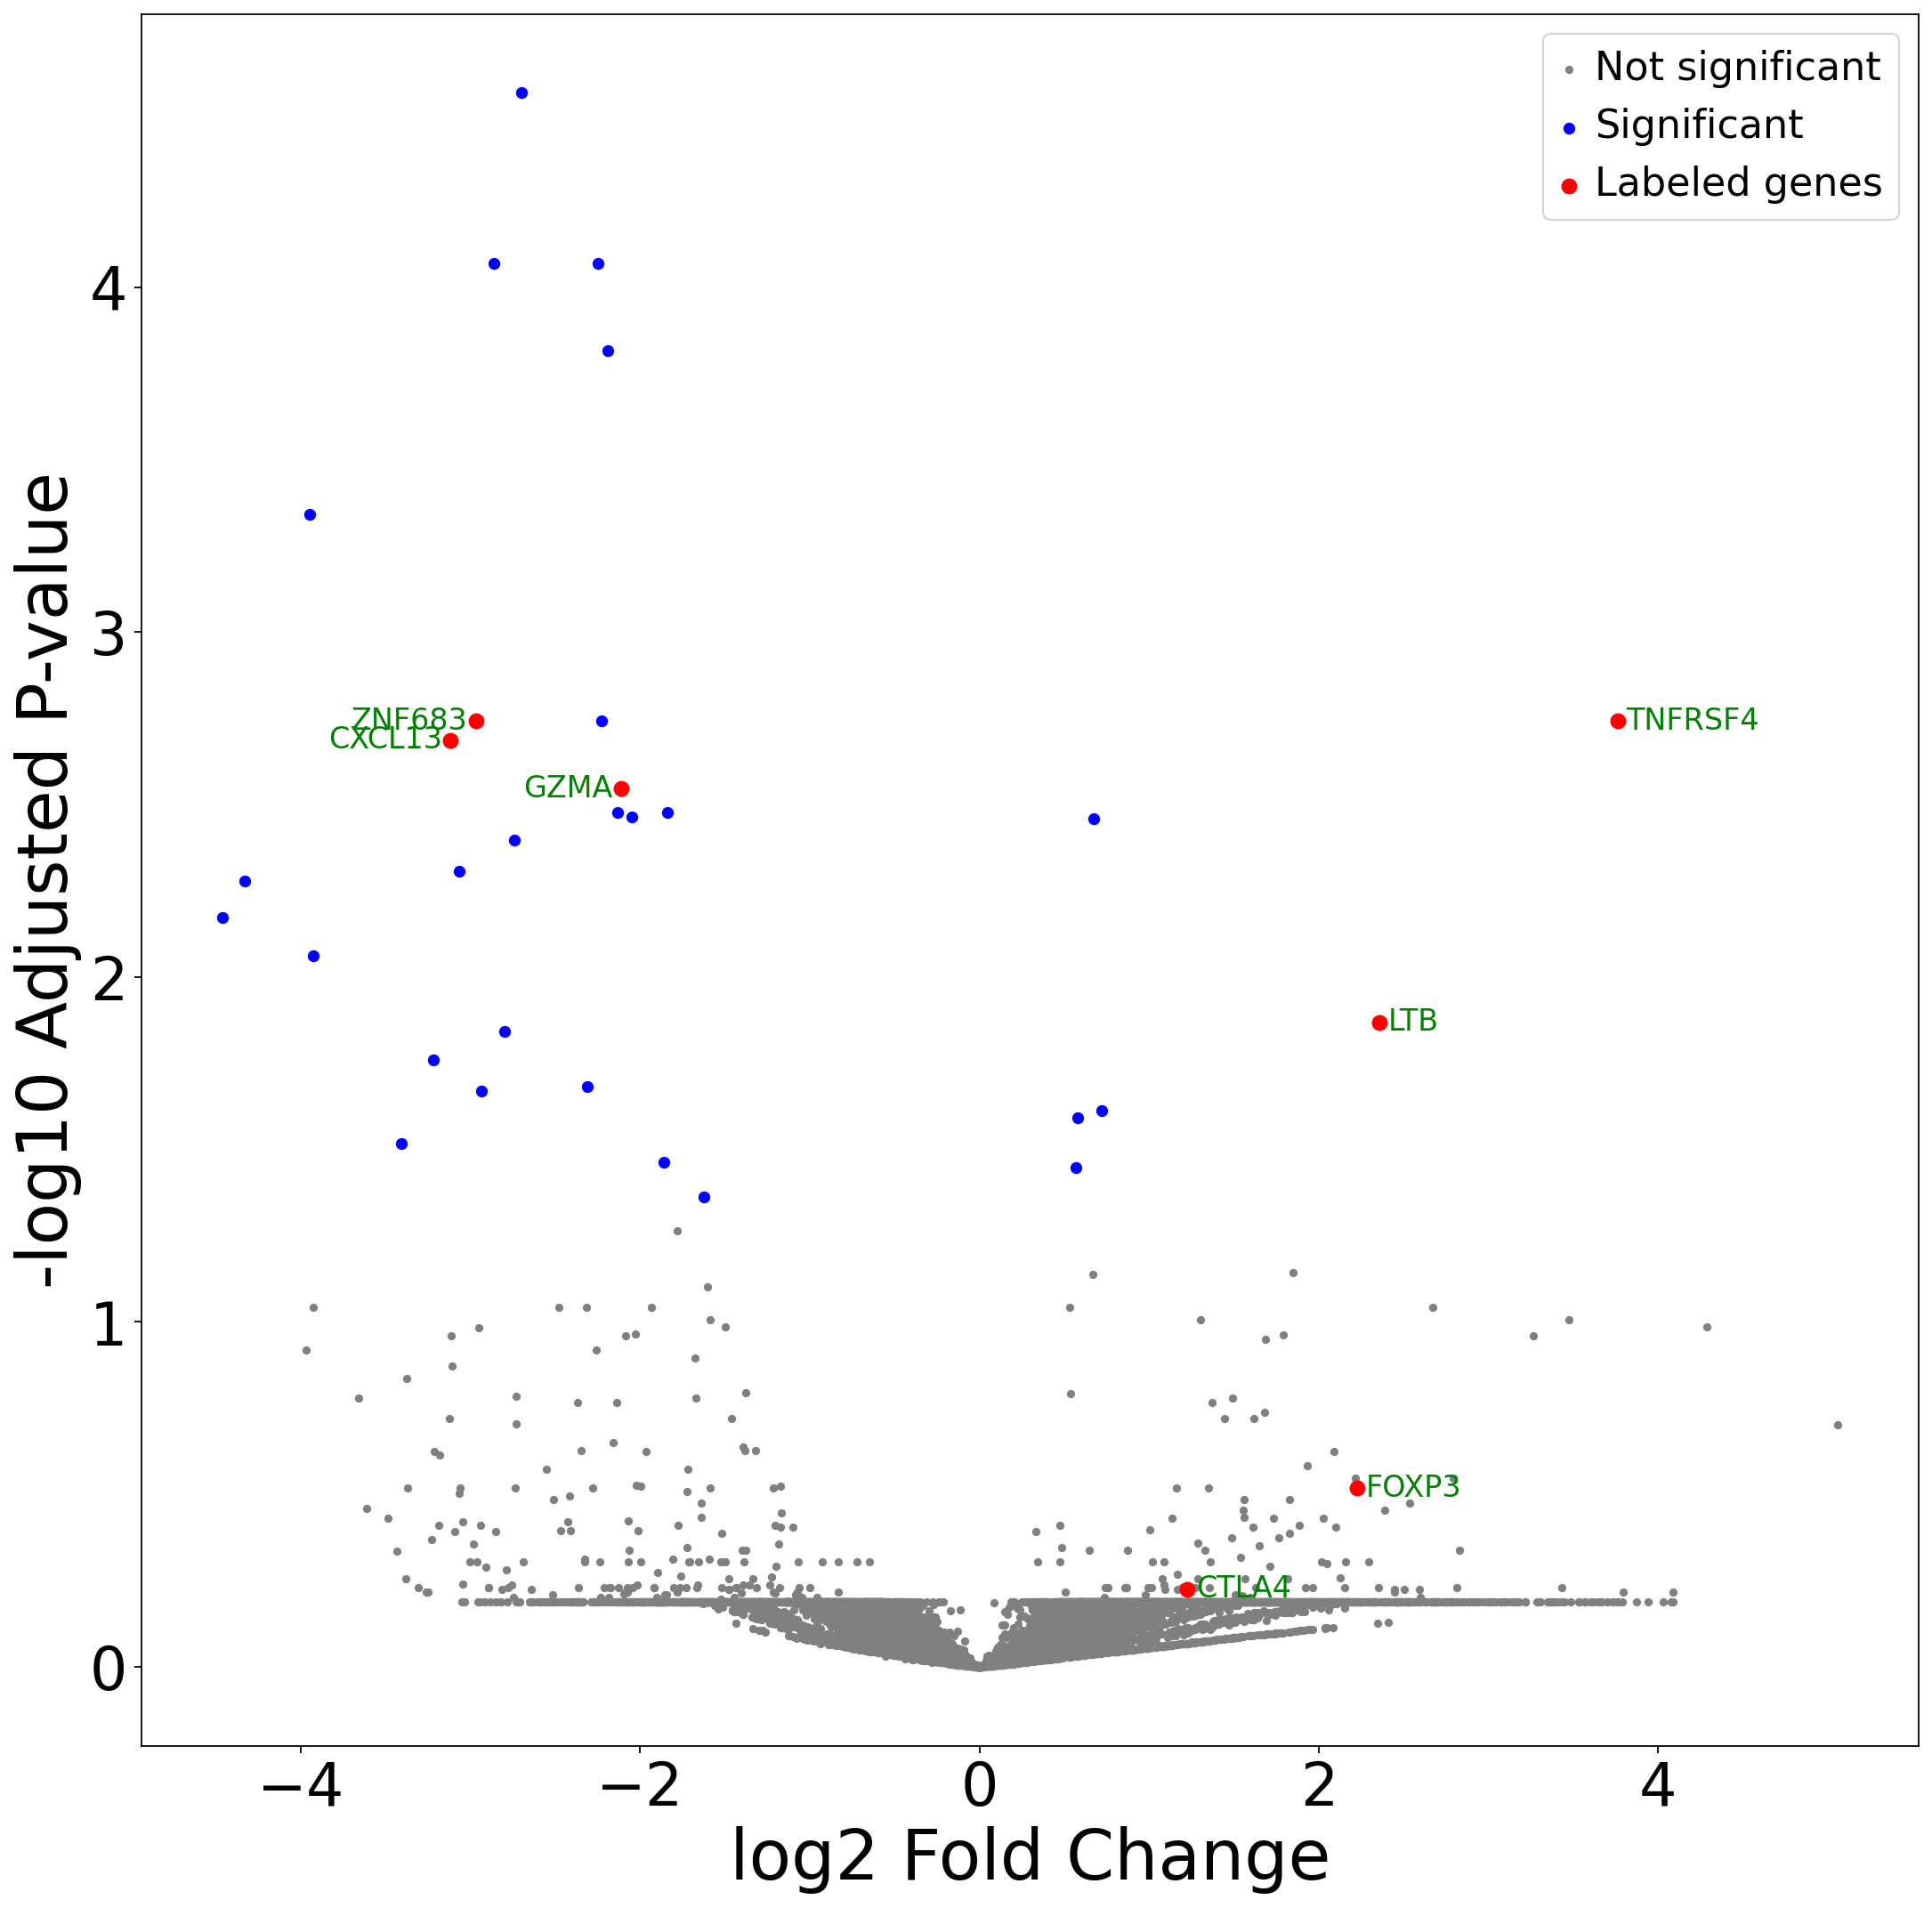

           names    scores  logfoldchanges         pvals  pvals_adj  log_pval
0        TNFRSF4  5.305075        3.763258  1.250190e-06   0.001813  2.741555
1         EEF1A1  4.825967        0.676207  4.097347e-06   0.003480  2.458419
2            LTB  4.471741        2.356302  2.230348e-05   0.013531  1.868677
3          RPS12  4.185680        0.577673  5.421961e-05   0.025584  1.592038
4           RPS8  4.153984        0.721659  4.966325e-05   0.024335  1.613769
...          ...       ...             ...           ...        ...       ...
12734  LINC02446 -5.388872       -3.947093  2.152653e-07   0.000457  3.340008
12735    ALOX5AP -5.772573       -2.192412  6.015486e-08   0.000153  3.814530
12736     CLEC2B -5.862020       -2.248857  2.683903e-08   0.000085  4.068124
12737       CCL5 -6.188574       -2.860330  2.128660e-08   0.000085  4.068124
12738      KLRK1 -6.206058       -2.698397  4.297335e-09   0.000027  4.562661

[9630 rows x 6 columns]
        names    scores  logfoldchanges

In [68]:
# Merging to make volcano plot, can change to 
data_foxp3_cd8_subset.obs['foxp3_pos'] = 'yes'
data_cxcl13_cd8_subset.obs['foxp3_pos'] = 'no'
# data_foxp3_cd8_subset2.obs['foxp3_pos'] = 'yes'
# data_cxcl13_cd4_subset.obs['foxp3_pos'] = 'no'

merged_data = sc.AnnData.concatenate(data_foxp3_cd8_subset, data_cxcl13_cd8_subset, join='outer')
# can change data_foxp3_cd8_subset to data_foxp3_cd8_subset2 AND data_cxcl13_cd8_subset to data_cxcl13_cd4_subset
print(merged_data.obs['foxp3_pos'].value_counts())

# prep for volcano plot
def deg_res(adata):
    adata.var['nonz_variance'] = (adata.X > 0).sum(axis=0).A.squeeze()
    
    adata = adata[:, adata.var['nonz_variance'] > 0]
    sc.tl.rank_genes_groups(adata, 'foxp3_pos', method='t-test')

    return sc.get.rank_genes_groups_df(adata, group='yes')

mydf_res = deg_res(merged_data)

# volcano plot function
def vol_plot(df_something, labeled_genes, p_value_cutoff=0.05, fold_change_cutoff=0, log_pval_cutoff=0, save_path=None):
    # Define significant genes
    significant_genes = (
        (df_something['pvals_adj'] < p_value_cutoff) &
        (np.abs(df_something['logfoldchanges']) > np.log2(fold_change_cutoff))
    )
    
    # Create a mask for labeled genes
    labeled_genes_mask = df_something['names'].isin(labeled_genes)
    
    # Cap -log10(pvals_adj) at 250
    df_something['log_pval'] = df_something['pvals_adj'].apply(lambda x: min(-np.log10(x), 250))

    # Plotting
    plt.figure(figsize=(16, 16))

    # Plot non-significant genes
    plt.scatter(
        x=df_something[~significant_genes]['logfoldchanges'], 
        y=df_something[~significant_genes]['log_pval'], 
        s=10, label="Not significant", c='gray'
    )

    # Plot significant genes
    plt.scatter(
        x=df_something[significant_genes]['logfoldchanges'], 
        y=df_something[significant_genes]['log_pval'], 
        s=25, label="Significant", c='blue'
    )

    # Plot and annotate labeled genes
    labeled = df_something[labeled_genes_mask]
    plt.scatter(
        x=labeled['logfoldchanges'], 
        y=labeled['log_pval'], 
        s=50, label="Labeled genes", c='red'
    )

    for gene, x, y in zip(labeled['names'], labeled['logfoldchanges'], labeled['log_pval']):
        ha = 'left' if x > 0 else 'right'
        plt.annotate(gene, (x + (0.05 if x > 0 else -0.05), y), fontsize=15, ha=ha, va='center', color='green')

    # Formatting
    plt.xticks(fontsize=30)
    plt.yticks(fontsize=30)
    plt.xlabel("log2 Fold Change", fontsize=35)
    plt.ylabel("-log10 Adjusted P-value", fontsize=35)
    plt.legend(fontsize=20)
    plt.grid(False)

    # Save if path is provided
    if save_path:
        plt.savefig(save_path, format='pdf', dpi=300, bbox_inches='tight')
        plt.show()

    plt.close()

# volcano plot output
df_res_sub_10 = mydf_res[abs(mydf_res['logfoldchanges']) < 10]
df_res_gte_10 = mydf_res[abs(mydf_res['logfoldchanges']) >= 10]

sc.set_figure_params(facecolor="white", figsize=(16, 16))


labeled = ['LTB','TNFRSF4','ZNF683','GZMA','CXCL13','TCF7','CCR7','FOXP3','CTLA4']  
vol_plot(df_res_sub_10, labeled)
vol_plot(df_res_sub_10, labeled, save_path='pilot.pdf')

print(df_res_sub_10)
print(df_res_sub_10.head(50))
print(df_res_sub_10.tail(50))